In [6]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
DIR_PATH = os.path.join('../../','data')

In [7]:
dataset = pd.read_csv(os.path.join(DIR_PATH, 'churn_conver.csv'))
len(dataset)

7043

In [8]:
# 0. 数据预处理
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            7043 non-null   int64  
 1   Partner                                  7043 non-null   int64  
 2   Dependents                               7043 non-null   int64  
 3   tenure                                   7043 non-null   int64  
 4   OnlineSecurity                           7043 non-null   int64  
 5   OnlineBackup                             7043 non-null   int64  
 6   DeviceProtection                         7043 non-null   int64  
 7   TechSupport                              7043 non-null   int64  
 8   StreamingTV                              7043 non-null   int64  
 9   StreamingMovies                          7043 non-null   int64  
 10  MonthlyCharges                           7043 non-null   fl

如果使用"全部预测为未流失"作为基线：
- 准确率：73.46%
- 召回率（流失）：0%
- F1-Score（流失）：0

In [9]:
# 1. 类别分布分析
churn_num = dataset['Churn'].sum()
print(f'churn number:{churn_num}')
print(f'churn rate:{churn_num/len(dataset)*100:.2f}%')

churn number:1869
churn rate:26.54%


#### 计算单特征对目标群体的贡献率


In [10]:
# 2. 相关性分析
from sklearn.feature_selection import mutual_info_classif
# 计算互信息 I(X;Y) = H(X) - H(X|Y)
def cal_mutual_info(name, discrete=True):
    mi = mutual_info_classif(dataset[[name]], dataset['Churn'], discrete_features=discrete)
    print(f'{name}的互信息:{mi[0]}')
cal_mutual_info('tenure',False)
cal_mutual_info('PhoneServiceAtt')
cal_mutual_info('OnlineSecurity')
cal_mutual_info('OnlineBackup')
cal_mutual_info('DeviceProtection')
cal_mutual_info('TechSupport')
cal_mutual_info('StreamingTV')
cal_mutual_info('StreamingMovies')
cal_mutual_info('MonthlyCharges',False)
cal_mutual_info('TotalCharges',False)



tenure的互信息:0.07118179444752415
PhoneServiceAtt的互信息:0.0008012658524292199
OnlineSecurity的互信息:0.06467728245735829
OnlineBackup的互信息:0.04679232253922637
DeviceProtection的互信息:0.04391690927485155
TechSupport的互信息:0.06302103606897548
StreamingTV的互信息:0.031907975162527094
StreamingMovies的互信息:0.03200094959522297
MonthlyCharges的互信息:0.04755238016672636
TotalCharges的互信息:0.04382399945050097


###  构造组合特征

In [11]:
# 创建组合特征：费用 × 合同类型
mean = dataset['MonthlyCharges'].mean()
print('mean:', mean)
std = dataset['MonthlyCharges'].std()
print('std',std)
dataset['middle_charge_short_contract'] = (
    (dataset['MonthlyCharges'] > mean - std) &
    (dataset['Contract_Month-to-month'] == 1)
).astype(int)

cal_mutual_info('middle_charge_short_contract')


mean: 64.76169246059918
std 30.090047097678493
middle_charge_short_contract的互信息:0.08999438010937515


In [12]:
dataset['phoneAndInternet'] = (
    (dataset['PhoneServiceAtt'] > 1) &
    ((dataset['InternetService_Fiber optic'] == 1) | dataset['InternetService_DSL'] == 1 )
).astype(int)

cal_mutual_info('phoneAndInternet')

phoneAndInternet的互信息:0.004416325315534875


### 查看连续值特征的分布情况

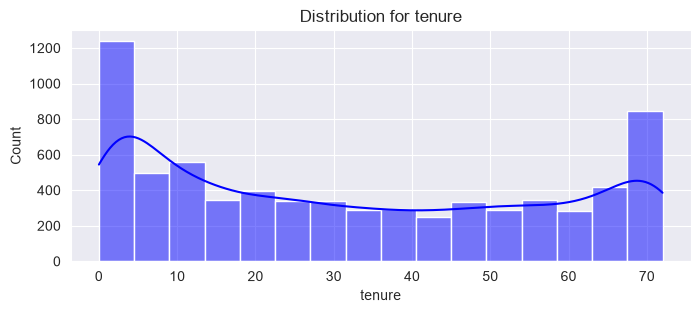

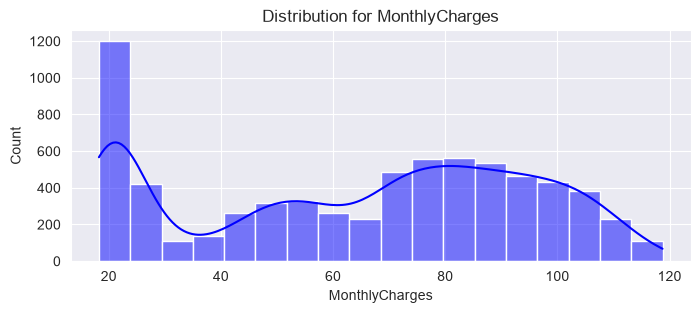

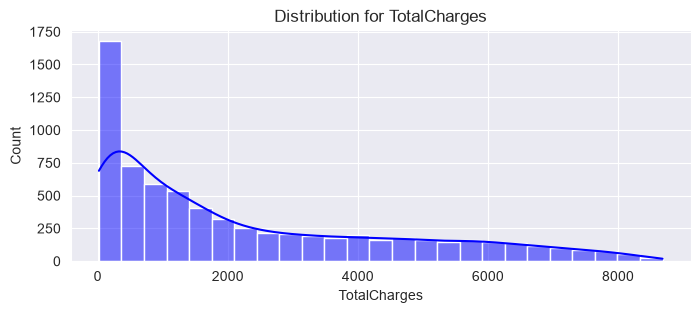

In [16]:
def feature_plot(feature, frame, color='b'):
    plt.figure(figsize=(8,3))
    plt.title("Distribution for {}".format(feature))
    ax = sns.histplot(frame[feature], color= color,kde=True)
num_cols = ["tenure", 'MonthlyCharges', 'TotalCharges']
for feat in num_cols: feature_plot(feat, dataset)